In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import optuna
import os
from contextlib import redirect_stdout


pd.set_option('display.max_columns', None)

In [16]:
df = pd.read_csv("../dataset/student.csv")
print(f"Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully: 1044 rows, 33 columns


In [17]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [18]:
for col in ["Mjob", "Fjob", "reason", "guardian"]:
    dummies = pd.get_dummies(df[col], prefix=col)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

df = df.drop(columns=["school"])

df["sex_male"] = df["sex"] == "M"
df["parent_together"] = df["Pstatus"] == "T"
df["famsize_large"] = df["famsize"] == "GT3"
df["address"] = df["address"] == "U"

mapping = {1: 60, 2: 210, 3: 450, 4: 720}
df["traveltime_minutes"] = df["traveltime"].map(mapping)
df["studytime_minutes"] = df["studytime"].map(mapping)

for col in ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]:
    df[col] = (df[col] == "yes").astype(int)

for col in ["G1", "G2", "G3"]:
    df[col] = df[col] * 5


df["avg_parent_edu"] = (df["Medu"] + df["Fedu"]) / 2
df["total_support"] = df[["schoolsup", "famsup", "paid"]].sum(axis=1)
df["study_per_travel"] = df["studytime_minutes"] / (df["traveltime_minutes"] + 1)

df = df.drop(columns=["schoolsup","address" , "Pstatus", "famsup", "paid", "studytime_minutes", "traveltime_minutes", "studytime", "Medu", "Fedu", "sex", "famsize"])

In [19]:
df.head()

,age,traveltime,failures,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,sex_male,parent_together,famsize_large,avg_parent_edu,total_support,study_per_travel
0,18,2,0,0,1,1,0,0,4,3,4,1,1,3,6,25,30,30,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,True,4.0,1,0.995261
1,17,1,0,0,0,1,1,0,5,3,3,1,1,3,4,25,25,30,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True,True,1.0,1,3.442623
2,15,1,3,0,1,1,1,0,4,3,2,2,3,3,10,35,40,50,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,1.0,2,3.442623
3,15,1,0,1,1,1,1,1,3,2,2,1,1,5,2,75,70,75,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True,True,3.0,2,7.377049
4,16,1,0,0,1,1,0,0,4,3,2,1,2,5,4,30,50,50,False,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,True,True,3.0,2,3.442623


In [20]:
X = df.drop(columns=["G3"]).select_dtypes(include=[np.number])
y = df["G3"]

selector = SelectFromModel(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1), 
    threshold="median"
)
selector.fit(X, y)
X_selected = selector.transform(X)
print(f"Selected {X_selected.shape[1]} features from {X.shape[1]} total features")

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

Selected 10 features from 20 total features


In [21]:
def rf_objective(trial: optuna.trial.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    score = -cross_val_score(model, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    return score


rf_study = optuna.create_study(direction="minimize")
with open(os.devnull, 'w') as devnull, redirect_stdout(devnull):
    rf_study.optimize(rf_objective, n_trials=40, show_progress_bar=True)

rf_best_params = rf_study.best_params
rf_best_params.update({"random_state": 42, "n_jobs": -1})
rf_optuna_model = RandomForestRegressor(**rf_best_params)
rf_optuna_model.fit(X_train, y_train)

rf_pred_test = rf_optuna_model.predict(X_test)
rf_pred_train = rf_optuna_model.predict(X_train)

rf_rmse = mean_squared_error(y_test, rf_pred_test) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_pred_test)
rf_r2 = r2_score(y_test, rf_pred_test)
rf_train_r2 = r2_score(y_train, rf_pred_train)
rf_generalization_gap = rf_train_r2 - rf_r2

print("RF Best params (Optuna):", rf_best_params)
print("RF Test RMSE:", rf_rmse)
print("RF Test R^2:", rf_r2)
print("RF Test MAE:", rf_mae)
print("RF Train R^2:", rf_train_r2)
print("RF generalization gap:", rf_generalization_gap)

[I 2026-04-02 23:25:05,524] A new study created in memory with name: no-name-2bafc4cd-d18d-41e2-b44c-ef90faa06aa6


  0%|          | 0/40 [00:00<?, ?it/s]

RF Best params (Optuna): {'n_estimators': 503, 'max_depth': 6, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': None, 'random_state': 42, 'n_jobs': -1}
RF Test RMSE: 8.15017835304765
RF Test R^2: 0.8281451697912224
RF Test MAE: 4.553701926149362
RF Train R^2: 0.9092347892186884
RF generalization gap: 0.08108961942746595


In [22]:
def xgb_objective(trial: optuna.trial.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "verbosity": 0,
        "n_jobs": -1,
    }
    model = XGBRegressor(**params)
    score = -cross_val_score(model, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    return score


xgb_study = optuna.create_study(direction="minimize")
with open(os.devnull, 'w') as devnull, redirect_stdout(devnull):
    xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

xgb_best_params = xgb_study.best_params
xgb_best_params.update({
    "random_state": 42,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "verbosity": 0,
    "n_jobs": -1,
})

xgb_optuna_model = XGBRegressor(**xgb_best_params)
xgb_optuna_model.fit(X_train, y_train)

xgb_pred_test = xgb_optuna_model.predict(X_test)
xgb_pred_train = xgb_optuna_model.predict(X_train)

xgb_rmse = mean_squared_error(y_test, xgb_pred_test) ** 0.5
xgb_mae = mean_absolute_error(y_test, xgb_pred_test)
xgb_r2 = r2_score(y_test, xgb_pred_test)
xgb_train_r2 = r2_score(y_train, xgb_pred_train)
xgb_generalization_gap = xgb_train_r2 - xgb_r2

print("XGB Best params (Optuna):", xgb_best_params)
print("XGB Test RMSE:", xgb_rmse)
print("XGB Test R^2:", xgb_r2)
print("XGB Test MAE:", xgb_mae)
print("XGB Train R^2:", xgb_train_r2)
print("XGB generalization gap:", xgb_generalization_gap)

[I 2026-04-02 23:26:32,013] A new study created in memory with name: no-name-0fd590a5-df18-453c-8a19-3e75a5dac614


  0%|          | 0/50 [00:00<?, ?it/s]

XGB Best params (Optuna): {'n_estimators': 356, 'learning_rate': 0.010249221530476178, 'max_depth': 4, 'min_child_weight': 6.346080770837151, 'subsample': 0.699488885659476, 'colsample_bytree': 0.9495625566461593, 'gamma': 0.2675576520171639, 'reg_alpha': 0.2666490731776715, 'reg_lambda': 0.000323086461626953, 'random_state': 42, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'verbosity': 0, 'n_jobs': -1}
XGB Test RMSE: 8.071865113385593
XGB Test R^2: 0.8314319252967834
XGB Test MAE: 4.64543342590332
XGB Train R^2: 0.9173702001571655
XGB generalization gap: 0.08593827486038208


In [23]:
print("\n===================== MODEL COMPARISON =====================")
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [rf_rmse, xgb_rmse],
    'R²': [rf_r2, xgb_r2],
    'MAE': [rf_mae, xgb_mae]
})

print(comparison.to_string(index=False))
best_model = 'XGBoost' if xgb_r2 > rf_r2 else 'Random Forest'
print(f"\nBest model: {best_model}")


===================== MODEL COMPARISON =====================
        Model     RMSE       R²      MAE
Random Forest 8.150178 0.828145 4.553702
      XGBoost 8.071865 0.831432 4.645433

Best model: XGBoost


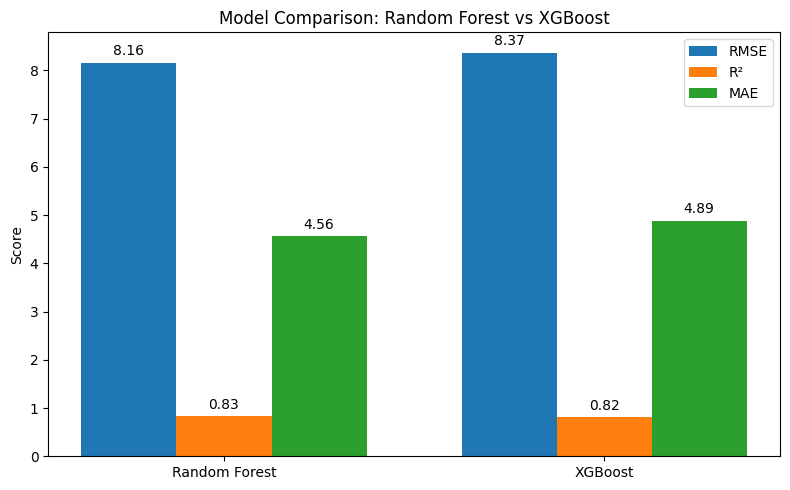

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
models = ['Random Forest', 'XGBoost']
rmse = [8.161105, 8.368652]
r2 = [0.827684, 0.818808]
mae = [4.564533, 4.886884]

x = np.arange(len(models))  # label locations
width = 0.25  # width of the bars

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot RMSE, R2, MAE side by side
rects1 = ax1.bar(x - width, rmse, width, label='RMSE')
rects2 = ax1.bar(x, r2, width, label='R²')
rects3 = ax1.bar(x + width, mae, width, label='MAE')

# Add labels, title, and legend
ax1.set_ylabel('Score')
ax1.set_title('Model Comparison: Random Forest vs XGBoost')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()

# Annotate bars with values
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [25]:
# Select the best model based on R² (highest is best)
best_model_r2 = max(rf_r2, xgb_r2)
if rf_r2 > xgb_r2:
    best_estimator = rf_optuna_model
    best_predictions = rf_pred_test
    best_model_name = 'Random Forest (Optuna)'
    best_model_rmse = rf_rmse
    best_model_mae = rf_mae
    is_rf = True
else:
    best_estimator = xgb_optuna_model
    best_predictions = xgb_pred_test
    best_model_name = 'XGBoost (Optuna)'
    best_model_rmse = xgb_rmse
    best_model_mae = xgb_mae
    is_rf = False

print(f"\nBEST MODEL: {best_model_name}")
print(f"   RMSE: {best_model_rmse:.4f}")
print(f"   R²: {best_model_r2:.4f}")
print(f"   MAE: {best_model_mae:.4f}")
print(f"   Type: {'Random Forest' if is_rf else 'XGBoost'}")


BEST MODEL: XGBoost (Optuna)
   RMSE: 8.0719
   R²: 0.8314
   MAE: 4.6454
   Type: XGBoost


Top features by average SHAP impact:


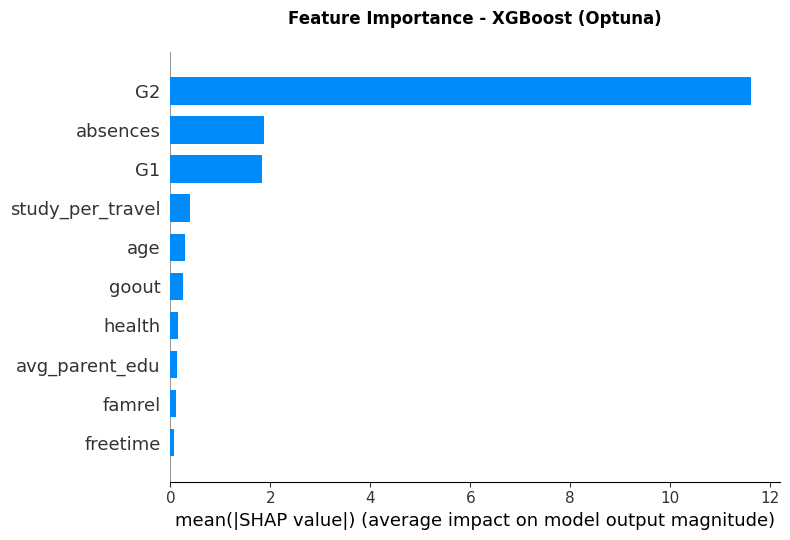


Feature impact on predictions:


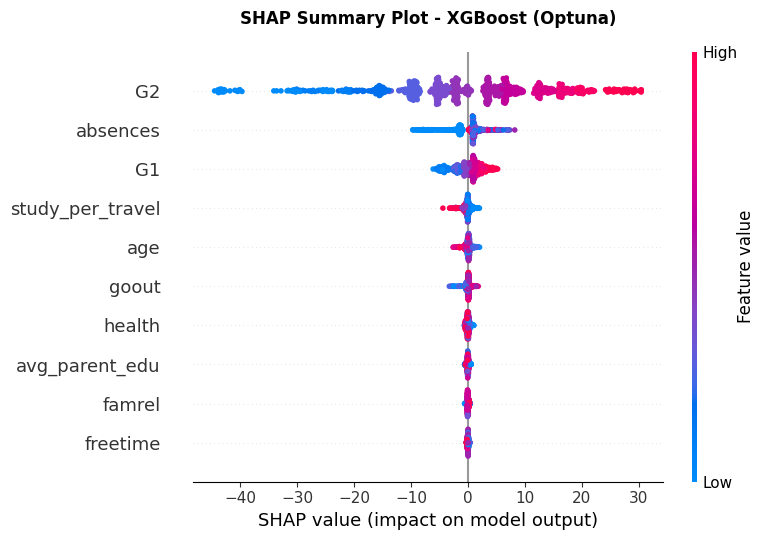

In [26]:
# Get feature names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
X_train_df = pd.DataFrame(X_train, columns=selected_features)
X_test_df = pd.DataFrame(X_test, columns=selected_features)

# Create explainer based on model type
if is_rf:
    explainer_best = shap.TreeExplainer(best_estimator)
    shap_values_best = explainer_best.shap_values(X_train_df)
    expected_value = explainer_best.expected_value
else:
    # For XGBoost
    explainer_best = shap.TreeExplainer(best_estimator)
    shap_values_best = explainer_best.shap_values(X_train_df)
    expected_value = explainer_best.expected_value

# Summary plot - Feature importance
print("Top features by average SHAP impact:")
shap.summary_plot(shap_values_best, X_train_df, plot_type="bar", show=False)
plt.title(f"Feature Importance - {best_model_name}", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nFeature impact on predictions:")
shap.summary_plot(shap_values_best, X_train_df, show=False)
plt.title(f"SHAP Summary Plot - {best_model_name}", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Explaining predictions from XGBoost (Optuna)...

Sample Predictions (first 5):
Actual    Predicted   Error     
--------------------------------
55.00     51.01       3.99      
40.00     41.82       1.82      
65.00     65.26       0.26      
55.00     55.48       0.48      
60.00     63.54       3.54      


SHAP Force Plot - Sample #1:
Actual value: 55.00
Predicted value: 50.21
(Base value = model's average prediction. Red = increases prediction, Blue = decreases)



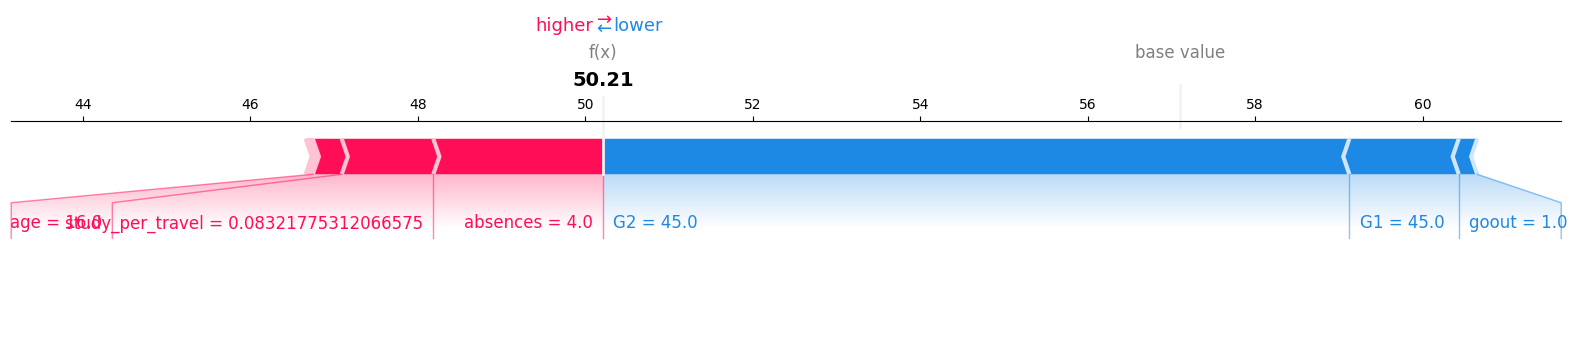

<Figure size 640x480 with 0 Axes>



Top Contributing Factors for Sample #1:
------------------------------------------------------------
 1. G2                        ↓ decreases     (-8.9112)
 2. absences                  ↑ increases     (+2.0281)
 3. G1                        ↓ decreases     (-1.3064)
 4. study_per_travel          ↑ increases     (+1.0936)
 5. age                       ↑ increases     (+0.3455)
 6. goout                     ↓ decreases     (-0.2206)
 7. health                    ↑ increases     (+0.0381)
 8. freetime                  ↑ increases     (+0.0252)
 9. avg_parent_edu            ↑ increases     (+0.0190)


In [27]:
print(f"Explaining predictions from {best_model_name}...\n")

# Show predictions vs actual for a few samples
print("Sample Predictions (first 5):")
print(f"{'Actual':<10}{'Predicted':<12}{'Error':<10}")
print("-" * 32)
for i in range(min(5, len(y_test))):
    actual = y_test.iloc[i]
    pred = best_predictions[i]
    error = abs(actual - pred)
    print(f"{actual:<10.2f}{pred:<12.2f}{error:<10.2f}")

# SHAP force plot for first sample
print(f"\n\nSHAP Force Plot - Sample #1:")
print(f"Actual value: {y_train.iloc[0]:.2f}")
print(f"Predicted value: {best_estimator.predict(X_train_df.iloc[0:1])[0]:.2f}")
print("(Base value = model's average prediction. Red = increases prediction, Blue = decreases)\n")

shap.force_plot(
    expected_value,
    shap_values_best[0],
    X_train_df.iloc[0],
    matplotlib=True
)
plt.tight_layout()
plt.show()

# Detailed explanation
def explain_prediction_detailed(shap_vals, features, threshold=0.01):
    """Generate human-readable explanation of prediction contributions."""
    contributions = []
    for i, feat in enumerate(features):
        if abs(shap_vals[i]) > threshold:
            impact = "↑ increases" if shap_vals[i] > 0 else "↓ decreases"
            contributions.append((feat, shap_vals[i], impact))
    
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    return contributions

print("\n\nTop Contributing Factors for Sample #1:")
print("-" * 60)
contributions = explain_prediction_detailed(shap_values_best[0], selected_features)
for i, (feat, impact_val, direction) in enumerate(contributions[:10], 1):
    print(f"{i:2}. {feat:<25} {direction:<15} ({impact_val:+.4f})")

## Visualization Suite

This section generates:
- SHAP summary bar plot (global feature importance)
- SHAP beeswarm plot (feature impact distribution)
- SHAP force plot (single student prediction)
- Target variable (G3) distribution
- Correlation heatmap of key features
- Actual vs Predicted values
- Cross-validation performance across folds

1) SHAP summary bar plot (global feature importance)


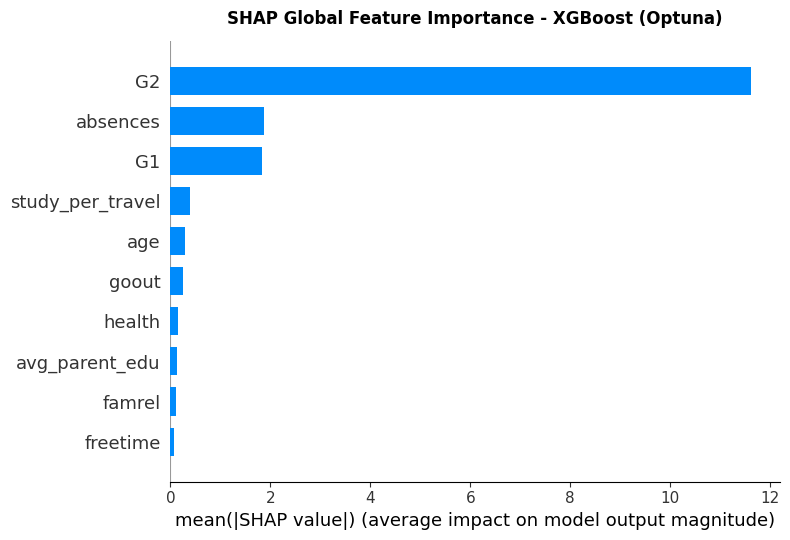

2) SHAP beeswarm plot (feature impact distribution)


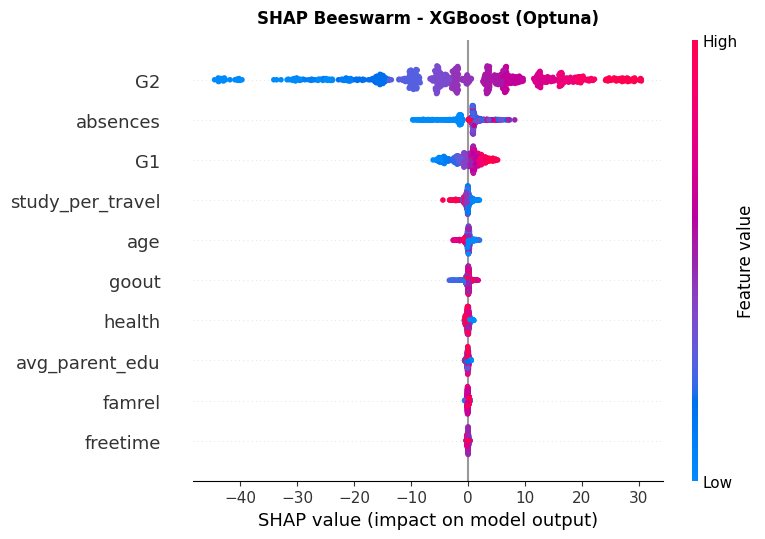

3) SHAP force plot (single student prediction)
Student index in test set: 0
Actual G3: 55.00
Predicted G3: 51.01


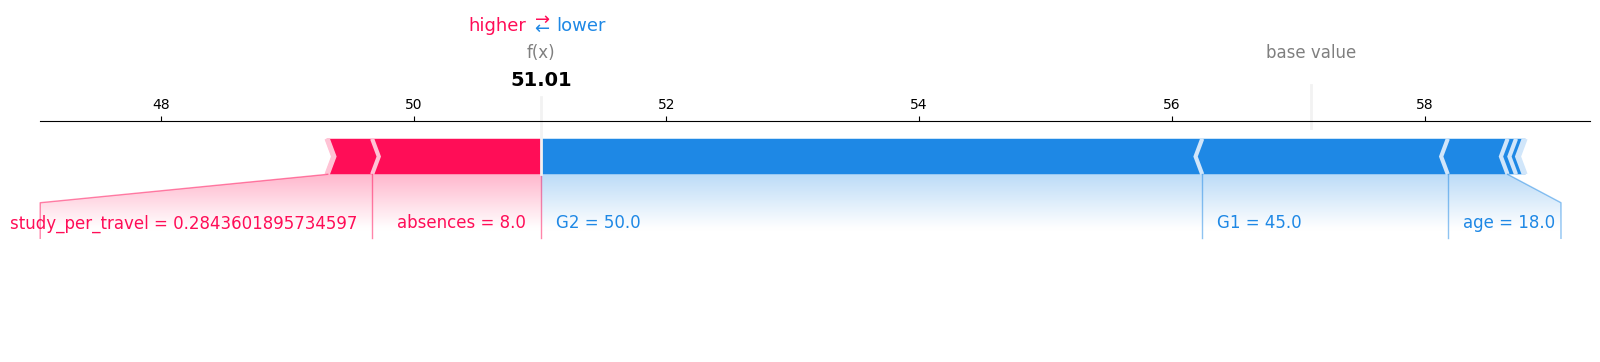

4) Distribution of target variable


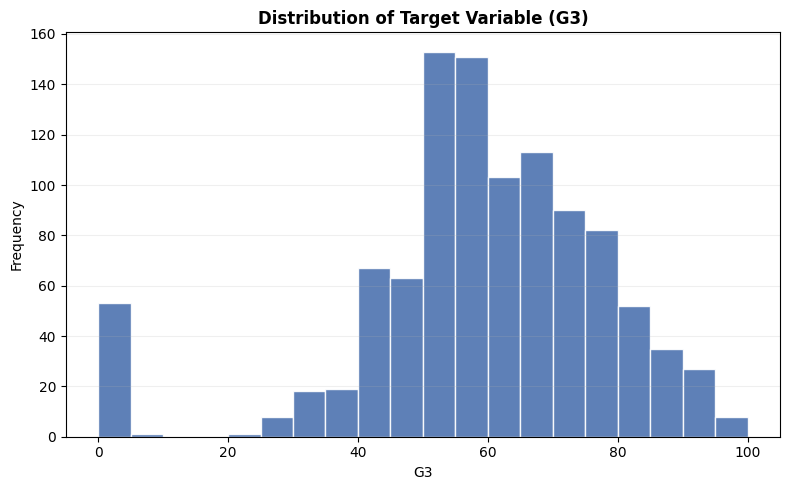

5) Correlation heatmap of key features


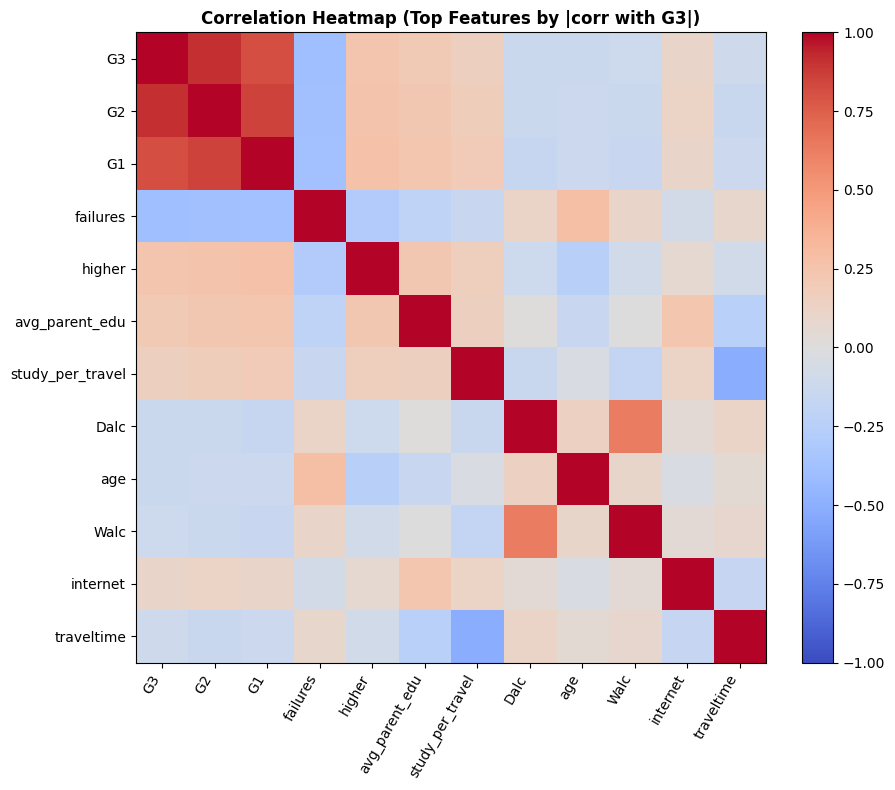

6) Actual vs Predicted values plot


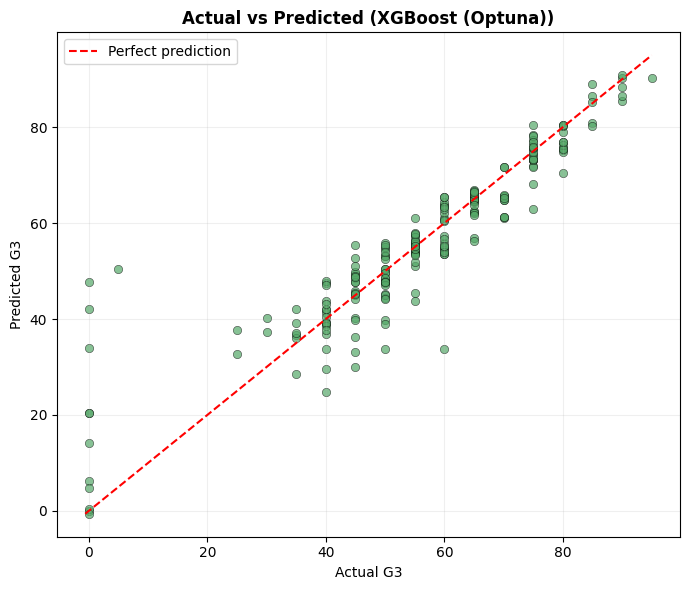

7) Cross-validation performance across folds


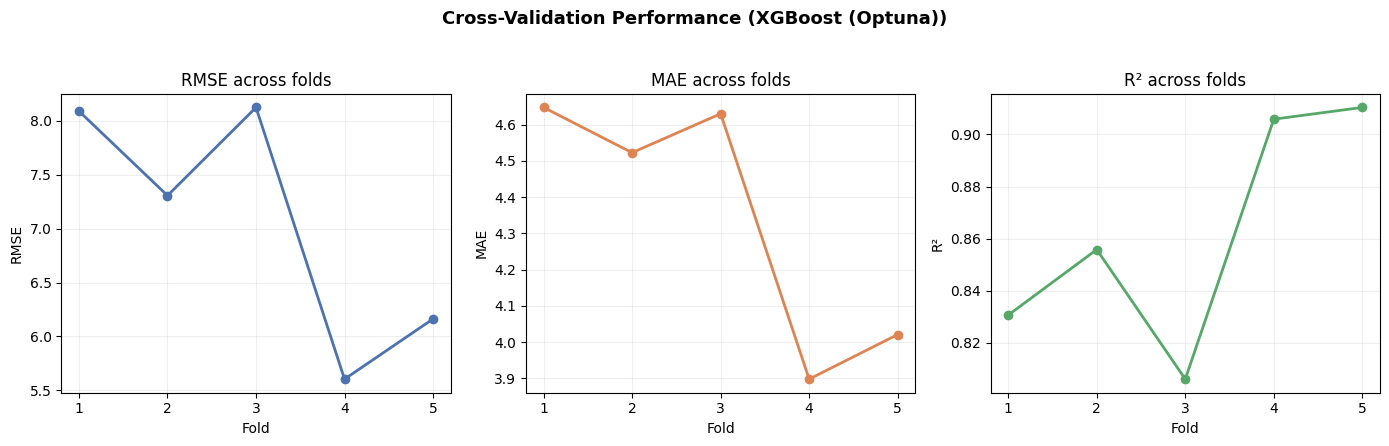


Cross-validation fold metrics:
 Fold     RMSE      MAE       R²
    1 8.090074 4.647589 0.830671
    2 7.306544 4.522619 0.855827
    3 8.124603 4.630192 0.806082
    4 5.603901 3.897726 0.905867
    5 6.162587 4.020811 0.910387


In [29]:
from sklearn.base import clone
from sklearn.model_selection import KFold

target_col = "G3"

# 1) SHAP summary bar plot (global feature importance)
print("1) SHAP summary bar plot (global feature importance)")
shap.summary_plot(shap_values_best, X_train_df, plot_type="bar", show=False)
plt.title(f"SHAP Global Feature Importance - {best_model_name}", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# 2) SHAP beeswarm plot (feature impact distribution)
print("2) SHAP beeswarm plot (feature impact distribution)")
shap.summary_plot(shap_values_best, X_train_df, show=False)
plt.title(f"SHAP Beeswarm - {best_model_name}", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# 3) SHAP force plot (single student prediction)
print("3) SHAP force plot (single student prediction)")
student_idx = 0
student_row = X_test_df.iloc[[student_idx]]
student_shap_values = explainer_best.shap_values(student_row)

print(f"Student index in test set: {student_idx}")
print(f"Actual {target_col}: {y_test.iloc[student_idx]:.2f}")
print(f"Predicted {target_col}: {best_estimator.predict(student_row.to_numpy())[0]:.2f}")

shap.force_plot(
    expected_value,
    student_shap_values[0],
    student_row.iloc[0],
    matplotlib=True,
)
plt.show()

# 4) Distribution of target variable
print("4) Distribution of target variable")
plt.figure(figsize=(8, 5))
plt.hist(y, bins=20, color="#4C72B0", edgecolor="white", alpha=0.9)
plt.title(f"Distribution of Target Variable ({target_col})", fontsize=12, fontweight="bold")
plt.xlabel(target_col)
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# 5) Correlation heatmap of key features
print("5) Correlation heatmap of key features")
numeric_df = df.select_dtypes(include=[np.number]).copy()
key_features = numeric_df.corr()[target_col].abs().sort_values(ascending=False).head(12).index
corr_matrix = numeric_df[key_features].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"Correlation Heatmap (Top Features by |corr with {target_col}|)", fontsize=12, fontweight="bold")
plt.xticks(range(len(key_features)), key_features, rotation=60, ha="right")
plt.yticks(range(len(key_features)), key_features)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 6) Actual vs Predicted values plot
print("6) Actual vs Predicted values plot")
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.7, color="#55A868", edgecolor="k", linewidth=0.4)
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect prediction")
plt.title(f"Actual vs Predicted ({best_model_name})", fontsize=12, fontweight="bold")
plt.xlabel(f"Actual {target_col}")
plt.ylabel(f"Predicted {target_col}")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 7) Cross-validation performance across folds
print("7) Cross-validation performance across folds")
cv = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmse, fold_mae, fold_r2 = [], [], []

for train_idx, test_idx in cv.split(X_selected):
    X_tr, X_te = X_selected[train_idx], X_selected[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model_cv = clone(best_estimator)
    model_cv.fit(X_tr, y_tr)
    y_pred = model_cv.predict(X_te)

    fold_rmse.append(mean_squared_error(y_te, y_pred) ** 0.5)
    fold_mae.append(mean_absolute_error(y_te, y_pred))
    fold_r2.append(r2_score(y_te, y_pred))

folds = np.arange(1, len(fold_rmse) + 1)

fig, axs = plt.subplots(1, 3, figsize=(14, 4.5))

axs[0].plot(folds, fold_rmse, marker="o", linewidth=2, color="#4C72B0")
axs[0].set_title("RMSE across folds")
axs[0].set_xlabel("Fold")
axs[0].set_ylabel("RMSE")
axs[0].set_xticks(folds)
axs[0].grid(alpha=0.2)

axs[1].plot(folds, fold_mae, marker="o", linewidth=2, color="#DD8452")
axs[1].set_title("MAE across folds")
axs[1].set_xlabel("Fold")
axs[1].set_ylabel("MAE")
axs[1].set_xticks(folds)
axs[1].grid(alpha=0.2)

axs[2].plot(folds, fold_r2, marker="o", linewidth=2, color="#55A868")
axs[2].set_title("R² across folds")
axs[2].set_xlabel("Fold")
axs[2].set_ylabel("R²")
axs[2].set_xticks(folds)
axs[2].grid(alpha=0.2)

plt.suptitle(f"Cross-Validation Performance ({best_model_name})", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

cv_results = pd.DataFrame({
    "Fold": folds,
    "RMSE": fold_rmse,
    "MAE": fold_mae,
    "R²": fold_r2,
})
print("\nCross-validation fold metrics:")
print(cv_results.to_string(index=False))